# Tutorial 3, Question 2b

In [35]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import time
import numpy as np
import matplotlib.pylab as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split

## Set learning parameters

In [36]:
no_epochs = 1000
lr = 0.01

SEED = 100
torch.manual_seed(SEED)
np.random.seed(SEED)

no_inputs = 4
no_outputs = 3

## Read input data

In [37]:
# reading the dataset
iris = datasets.load_iris()
iris.data -= np.mean(iris.data, axis=0)
    
x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=2)

print(np.shape(x_train))
print(np.shape(y_test))

(90, 4)
(60,)


## Write data input pytorch Datasets

In [38]:
class MyDataset(Dataset):
  def __init__(self, X, y):
    self.X =torch.tensor(X, dtype=torch.float)
    self.y =torch.tensor(y, dtype=torch.long)
    
  def __len__(self):
    return len(self.y)

  def __getitem__(self,idx):
    return self.X[idx], self.y[idx]

In [39]:
train_data = MyDataset(x_train, y_train)
test_data = MyDataset(x_test, y_test)

## Build a softmax layer

In [40]:
class SoftmaxLayer(nn.Module):
  def __init__(self, no_inputs, no_outputs):
        super().__init__()
        self.softmax_layer = nn.Sequential(
            nn.Linear(no_inputs, no_outputs),
        )

  def forward(self, x):
        logits = self.softmax_layer(x)
        return logits

## Functions for one loop of training and testing

In [41]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset) # number of samples in the dataset
    num_batches = len(dataloader) # number of batches in the dataloader
    
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    train_loss /= size
    correct /= size
    return train_loss, correct
    

def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= size
    correct /= size
 
    return test_loss, correct
    

## Training the model at various batch sizes

In [42]:
loss_fn = nn.CrossEntropyLoss()

batch_sizes = [2, 4, 8, 16, 24, 32, 48, 64]

acc_, t_ = [], []

for batch_size in batch_sizes:

    # create a softmaxlayer object
    model = SoftmaxLayer(no_inputs, no_outputs)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    
    # create data loaders for train and test data
    train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

    num_batches = len(train_dataloader)

    train_loss_, train_acc_, test_loss_, test_acc_ = [], [], [], []
    t = 0
    for epoch in range(no_epochs):
        start_time = time.time()
        train_loss, train_acc = train_loop(train_dataloader, model, loss_fn, optimizer)
        t += time.time() - start_time
        test_loss, test_acc = test_loop(test_dataloader, model, loss_fn)
        train_loss_.append(train_loss), train_acc_.append(train_acc)
        test_loss_.append(test_loss), test_acc_.append(test_acc)
        
    t_.append(t*1000/(no_epochs*num_batches))
    acc_.append(test_acc_[-1])
    print(f"batch-size {batch_size}: time {t_[-1]:>3f}ms, accuracy {acc_[-1]:>2f}")
    

batch-size 2: time 0.211285ms, accuracy 0.950000
batch-size 4: time 0.211191ms, accuracy 0.950000
batch-size 8: time 0.220582ms, accuracy 0.950000
batch-size 16: time 0.233568ms, accuracy 0.950000
batch-size 24: time 0.250176ms, accuracy 0.950000
batch-size 32: time 0.261550ms, accuracy 0.950000
batch-size 48: time 0.291437ms, accuracy 0.950000
batch-size 64: time 0.284657ms, accuracy 0.933333


## Plot time-taken-to-weight-update vs batch size

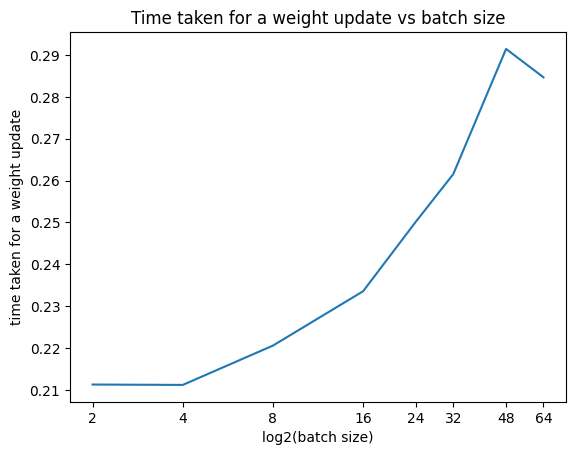

In [47]:
plt.figure(1)
plt.plot(np.log2(batch_sizes), t_)
plt.xticks(np.log2(batch_sizes), batch_sizes)
plt.xlabel('log2(batch size)')
plt.ylabel('time taken for a weight update')
plt.title('Time taken for a weight update vs batch size')
plt.show()

## Plot accuracy vs batch size

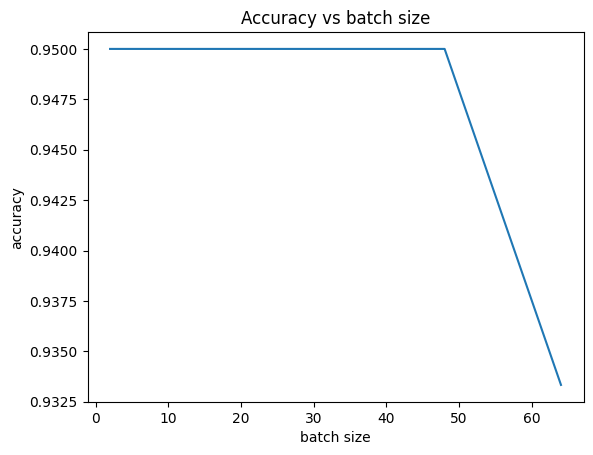

In [50]:
plt.figure(1)
plt.plot(batch_sizes, acc_)
plt.xlabel('batch size')
plt.ylabel('accuracy')
plt.title('Accuracy vs batch size')
plt.show()